In [968]:
import numpy as np
import matplotlib.pyplot as plt

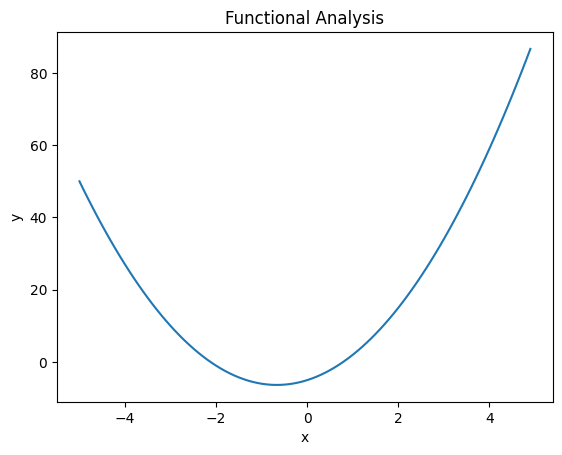

In [969]:
def f(x):
    """
    Simple function that takes 1 input and produces 1 output
    """
    return 3*x**2 + 4*x - 5

def get_derivative(fun, x, h):
    """
    Calculates the derivative of a given function at point x, using the change in a positive unit direction of h
    It will answer: If I slightly increase this x, what happens to the f(x)
    """
    return (fun(x + h) - fun(x)) / h

xs = np.arange(-5, 5, 0.1)
y = f(xs)
plt.title("Functional Analysis")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(xs, y)
plt.show()

In [970]:
h = 0.000001
x = 1
get_derivative(f, x, h) # How much f(x) will respond to a change of 'h' in a +ve direction at x = 1

10.000002999888125

In [971]:
def g(x1, x2, x3):
    return x1 ** 2 - 4 * x2 + 5 * x3 ** 3 - 5
h = 0.000001
x1 = 2
x2 = 3
x3 = 2
y =  g(x1, x2, x3)# Complex function that takes 3 input and produces 1 output
y

# Derivative of g at x1 = 2, Derivative of g at x2 = 3, Derivative of g at x3 =  2
dg_dx1 = (g(x1 + h, x2, x3) - y) / h # How much y will respond if i change x1 from x1 to x1 + h, h > 0
dg_dx2 = (g(x1, x2 + h, x3) - y) / h # How much y will respond if i change x1 from x1 to x1 + h, h > 0
dg_dx3 = (g(x1, x2, x3 + h) - y) / h # How much y will respond if i change x1 from x1 to x1 + h, h > 0

print(f"dg/dx1 = {dg_dx1:.5f}")
print(f"dg/dx2 = {dg_dx2:.5f}")
print(f"dg/dx3 = {dg_dx3:.5f}")

dg/dx1 = 4.00000
dg/dx2 = -4.00000
dg/dx3 = 60.00003


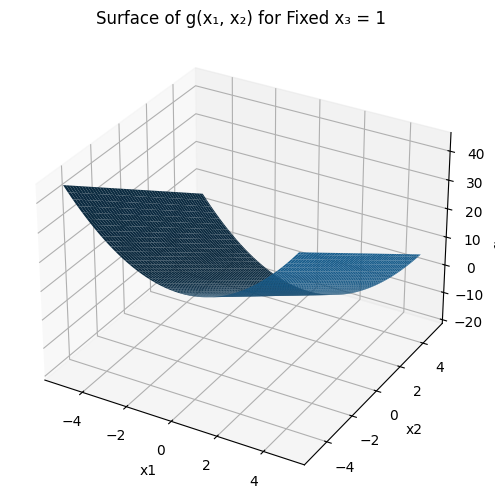

In [972]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)

X1, X2 = np.meshgrid(x1, x2)

# Fix x3 = 1
x3 = 1

# Function
Z = X1**2 - 4*X2 + 5*(x3**3) - 5

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Z)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")
plt.title("Surface of g(x₁, x₂) for Fixed x₃ = 1")
plt.show()

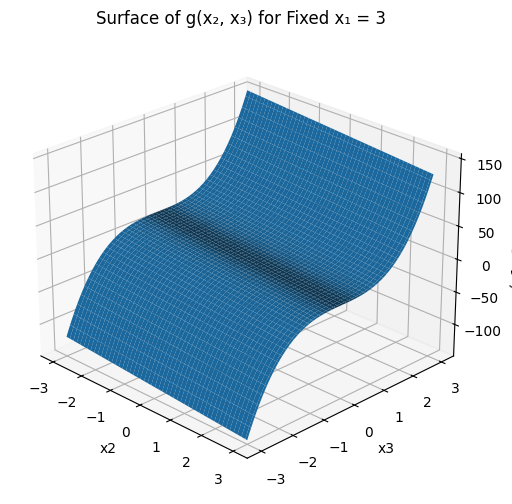

In [973]:
import numpy as np
import matplotlib.pyplot as plt

# Create ranges
x2 = np.linspace(-3, 3, 100)
x3 = np.linspace(-3, 3, 100)

# Create 2D grid
X2, X3 = np.meshgrid(x2, x3)

# Fix x1
x1 = 3

# Function
Z = x1**2 - 4*X2 + 5*(X3**3) - 5

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X2, X3, Z)

ax.set_xlabel("x2")
ax.set_ylabel("x3")
ax.set_zlabel("g(x1,x2,x3)")
ax.view_init(elev=25, azim=-45)

plt.title("Surface of g(x₂, x₃) for Fixed x₁ = 3")
plt.show()

In [974]:
# Interpretation

# dg/dx1 = 4.00000; at x1 = 2
# dg/dx2 = -4.00000; at x2 = 3
# dg/dx3 = 60.00003; at x3 = 2

# here we can clearly see that,
    # In fig 1, dg/dx1 = 4, and it's true that if we move a bit in x1 axis we will eventually increase g(x1, x2) a bit
    # In fig 1, dg/dx2 = -4, and it's true that if we move a bit in x2 axis we will eventually decrease g(x1, x2) a bit
    # In fig 2, dg/dx3 = 60, and it's true that if we move a bit in x3 axis we will get very good increase in g(x2, x3)

## Moving towards Neural Networks: Massive collection of functions

In [975]:
class Scalar:
    def __init__(self, data, _prev = (), _op = "", var_name = ""):
        self.data = data
        self.grad = 0
        self._prev = tuple(_prev)
        self._op = _op
        self.var_name = var_name
        self._backward = lambda: None

    def __repr__(self):
        return f"Scalar(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        out = Scalar(self.data + other.data, _prev = (other, self), _op = "+")
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        # self = self if isinstance(self, Scalar) else Scalar(self)
        out = Scalar(self.data - other.data, _prev = (other, self), _op = "-")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad -= 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        if other.data == 0:
            raise ZeroDivisionError("Division by zero")
        
        out = Scalar(self.data / other.data, _prev = (other, self), _op = "/")

        def _backward():
            self.grad += (1.0 / other.data) * out.grad
            other.grad += (-self.data / (other.data ** 2)) * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        out = Scalar(self.data * other.data, _prev = (other, self), _op = "*")
        # Store the Local gradients
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        other = other if isinstance(other, Scalar) else Scalar(other)
        out = Scalar(self.data ** other.data, _prev = (other, self), _op = f"**{other}")
        # c = a ** b ---> dc/da = b * a ** (b - 1); dc/db = (a ** b) * (ln(a))
        def _backward():
            self.grad += (other.data * (self.data ** (other.data - 1.0))) * out.grad
            # other.grad += ((self.data ** other.data) * np.log(self.data)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        tanh_x = ((np.exp(2*x) - 1) / (np.exp(2*x) + 1))
        out = Scalar(tanh_x, var_name = "tanh", _prev = (self, ), _op = "tanh")
        def _backward():
            self.grad += (1 - out.data**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        # To add this functionality we need to implement a topological sorting
        topo_sorted = []
        visited = set()
        def topo_sort(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    topo_sort(child)
                topo_sorted.append(v) # add the parent only after adding the child
        topo_sort(self)

        # Doing backprop on whole computatinal graph
        self.grad = 1.0
        for node in topo_sorted[::-1]:
            node._backward() # the Topological sorting will ensure that we are not calling backward before computing all the dependencies after the calling node
        


def trace(root):

    nodes = set()
    edges = set()

    def build(v):

        if v not in nodes:

            nodes.add(v)

            for child in v._prev:

                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

from graphviz import Digraph

def draw_dot(root):

    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:

        uid = str(id(n))

        # Data node
        dot.node(
            name=uid,
            label=f"{n.var_name} | data: {n.data:.4f} | grad: {n.grad:.4f}",
            shape='record'
        )

        # Operation node
        if n._op:

            op_id = uid + n._op

            dot.node(
                name=op_id,
                label=n._op
            )

            dot.edge(op_id, uid)

    for n1, n2 in edges:

        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [976]:
x1 = -3
x2 = 4
x3 = -4
x1 = Scalar(x1, var_name="x1")
x2 = Scalar(x2, var_name="x2")
z = x1 * x2; z.var_name = "z"
x3 = Scalar(x3, var_name="x3")
L = x3 + z # a.__add__(b.__pow__(c))
L; L.var_name = "L"

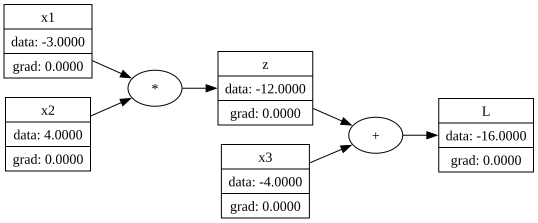

In [977]:
draw_dot(L)

----------------------------------------------- dL/dX -----------------------------------------------
dL/dx1 = -4.000000330961484
dL/dx2 = 8.000000661922968
dL/dx3 = -4.000000330961484
dL/dx4 = 4.000000330961484
dL/dx5 = 0.0
dL/dx6 = -1.000000082740371
dL/dx7 = 2.000000165480742
dL/dx8 = 1.000000082740371
----------------------------------------------- dL/dZ -----------------------------------------------
dL/dz1 = -4.000000330961484
dL/dz2 = -4.000000330961484
dL/dz3 = -4.000000330961484
dL/dz4 = 2.000000165480742
dL/dz5 = 4.000000330961484
dL/dz6 = 1.000000082740371


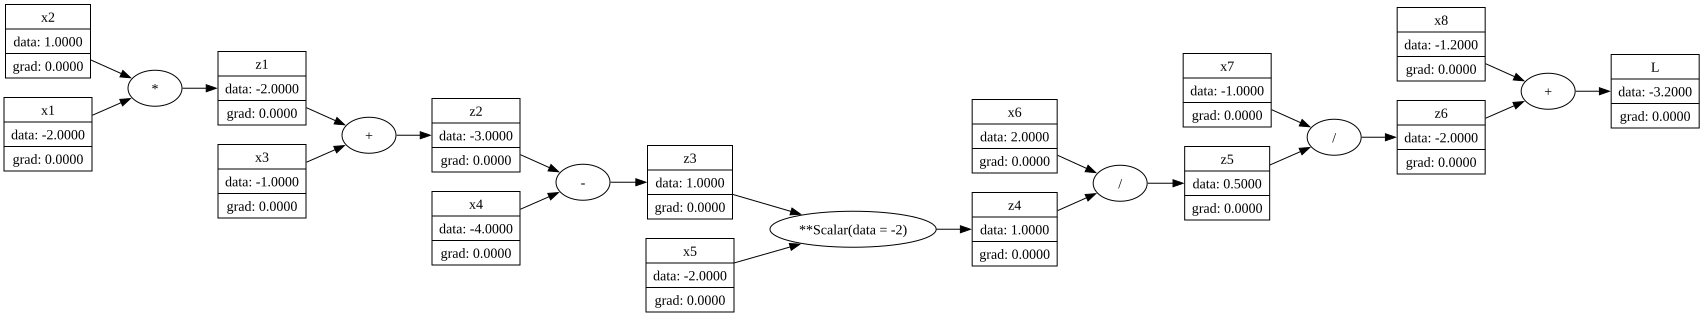

In [978]:
dh = 0.0000000001

def h(x1, x2, x3, x4, x5, x6, x7, x8):
    x1 = Scalar(x1, var_name="x1")
    x2 = Scalar(x2, var_name="x2")
    x3 = Scalar(x3, var_name="x3")
    x4 = Scalar(x4, var_name="x4")
    x5 = Scalar(x5, var_name="x5")
    x6 = Scalar(x6, var_name="x6")
    x7 = Scalar(x7, var_name="x7")
    x8 = Scalar(x8, var_name="x8")

    # Internal Computational Nodes
    z1 = x1 * x2; z1.var_name = "z1"
    z2 = z1 + x3; z2.var_name = "z2"
    z3 = z2 - x4; z3.var_name = "z3"
    z4 = z3 ** x5; z4.var_name = "z4"
    z5 = z4 / x6; z5.var_name = "z5"
    z6 = x7 / z5; z6.var_name = "z6"
    L = z6 + x8; L.var_name = "L"

    # Tracking their gradients directly
    global dh
    dh_local = Scalar(dh, var_name="dh")


    # dL/dz1
    z1 = x1 * x2; z1.var_name = "z1"
    z2_h = (z1 + dh_local) + x3; z2.var_name = "z2"
    z3 = z2_h - x4; z3.var_name = "z3"
    z4 = z3 ** x5; z4.var_name = "z4"
    z5 = z4 / x6; z5.var_name = "z5"
    z6 = x7 / z5; z6.var_name = "z6"
    L_z1 = z6 + x8

    dL_dz1 = (L_z1 - L) / dh_local

    # dL/dz2
    z1 = x1 * x2; z1.var_name = "z1"
    z2 = z1 + x3; z2.var_name = "z2"
    z3_h = (z2 + dh_local) - x4; z3.var_name = "z3"
    z4 = z3_h ** x5; z4.var_name = "z4"
    z5 = z4 / x6; z5.var_name = "z5"
    z6 = x7 / z5; z6.var_name = "z6"
    L_z2 = z6 + x8

    dL_dz2 = (L_z2 - L) / dh_local

    # dL/dz3
    z1 = x1 * x2; z1.var_name = "z1"
    z2 = z1 + x3; z2.var_name = "z2"
    z3 = z2 - x4; z3.var_name = "z3"
    z4_h = (z3 + dh_local) ** x5; z4.var_name = "z4"
    z5 = z4_h / x6; z5.var_name = "z5"
    z6 = x7 / z5; z6.var_name = "z6"
    L_z3 = z6 + x8

    dL_dz3 = (L_z3 - L) / dh_local

    # dL/dz4
    z1 = x1 * x2; z1.var_name = "z1"
    z2 = z1 + x3; z2.var_name = "z2"
    z3 = z2 - x4; z3.var_name = "z3"
    z4 = z3 ** x5; z4.var_name = "z4"
    z5_h = (z4 + dh_local) / x6; z5.var_name = "z5"
    z6 = x7 / z5_h; z6.var_name = "z6"
    L_z4 = z6 + x8

    dL_dz4 = (L_z4 - L) / dh_local

    # dL/dz5
    z1 = x1 * x2; z1.var_name = "z1"

    dL_dz1 = (L_z1 - L) / dh_local
    z2 = z1 + x3; z2.var_name = "z2"
    z3 = z2 - x4; z3.var_name = "z3"
    z4 = z3 ** x5; z4.var_name = "z4"
    z5 = z4 / x6; z5.var_name = "z5"
    z6_h = x7 / (z5 + dh_local); z6.var_name = "z6"
    L_z5 = z6_h + x8

    dL_dz5 = (L_z5 - L) / dh_local
    
    # dL/dz6
    z1 = x1 * x2; z1.var_name = "z1"
    z2 = z1 + x3; z2.var_name = "z2"
    z3 = z2 - x4; z3.var_name = "z3"
    z4 = z3 ** x5; z4.var_name = "z4"
    z5 = z4 / x6; z5.var_name = "z5"
    z6 = x7 / z5; z6.var_name = "z6"
    L_z6 = (z6 + dh_local) + x8

    dL_dz6 = (L_z6 - L) / dh_local

    return L, L.data, (dL_dz1.data, dL_dz2.data, dL_dz3.data, dL_dz4.data, dL_dz5.data, dL_dz6.data)


# ---------------------------------- Derivatives -------------------------------------
x1 = -2
x2 = 1
x3 = -1
x4 = -4
x5 = -2
x6 = 2
x7 = -1
x8 = -1.2
L_scalar, L, dL_dzs = h(x1, x2, x3, x4, x5, x6, x7, x8)
dL_dL = ((L + dh) - L) / dh
# ------------------------------------------------- dL/dX ------------------------------------------------- 
dL_dx1 = (h(x1 + dh, x2, x3, x4, x5, x6, x7, x8)[1] - L) / dh
dL_dx2 = (h(x1, x2 + dh, x3, x4, x5, x6, x7, x8)[1] - L) / dh
dL_dx3 = (h(x1, x2, x3 + dh, x4, x5, x6, x7, x8)[1] - L) / dh
dL_dx4 = (h(x1, x2, x3, x4 + dh, x5, x6, x7, x8)[1] - L) / dh
dL_dx5 = (h(x1, x2, x3, x4, x5 + dh, x6, x7, x8)[1] - L) / dh
dL_dx6 = (h(x1, x2, x3, x4, x5, x6 + dh, x7, x8)[1] - L) / dh
dL_dx7 = (h(x1, x2, x3, x4, x5, x6, x7 + dh, x8)[1] - L) / dh
dL_dx8 = (h(x1, x2, x3, x4, x5, x6, x7, x8 + dh)[1] - L) / dh
# # ------------------------------------------------- dL/dZ ------------------------------------------------- 
dL_dz1, dL_dz2, dL_dz3, dL_dz4, dL_dz5, dL_dz6 = dL_dzs

print("----------------------------------------------- dL/dX -----------------------------------------------")
print(f"dL/dx1 = {dL_dx1}")
print(f"dL/dx2 = {dL_dx2}")
print(f"dL/dx3 = {dL_dx3}")
print(f"dL/dx4 = {dL_dx4}")
print(f"dL/dx5 = {dL_dx5}")
print(f"dL/dx6 = {dL_dx6}")
print(f"dL/dx7 = {dL_dx7}")
print(f"dL/dx8 = {dL_dx8}")
print("----------------------------------------------- dL/dZ -----------------------------------------------")
print(f"dL/dz1 = {dL_dz1}")
print(f"dL/dz2 = {dL_dz2}")
print(f"dL/dz3 = {dL_dz3}")
print(f"dL/dz4 = {dL_dz4}")
print(f"dL/dz5 = {dL_dz5}")
print(f"dL/dz6 = {dL_dz6}")
# print(f"z = x1 * x2")
# print(f"L = x3 + z")
# print(f"dL/dx3 = (h(x1, x2, x3 + dh) - L) / dh = {dL_dx3:.3f}")
# print(f"dL/dz = (h(x1, x2, x3) - L) / dh = {dL_dz:.3f}")
# print(f"dL/dx2 = (h(x1, x2 + dh, x3) - L) / dh = {dL_dx2:.3f}")
# print(f"dL/dx1 = (h(x1 + dh, x2, x3 + dh) - L) / dh = {dL_dx1:.3f}")
draw_dot(L_scalar)

## Let's fill the Backwardpass graph manually

In [979]:
L_scalar._prev

(Scalar(data = -1.2), Scalar(data = -2.0))

Computational Graph for forward and backward pass


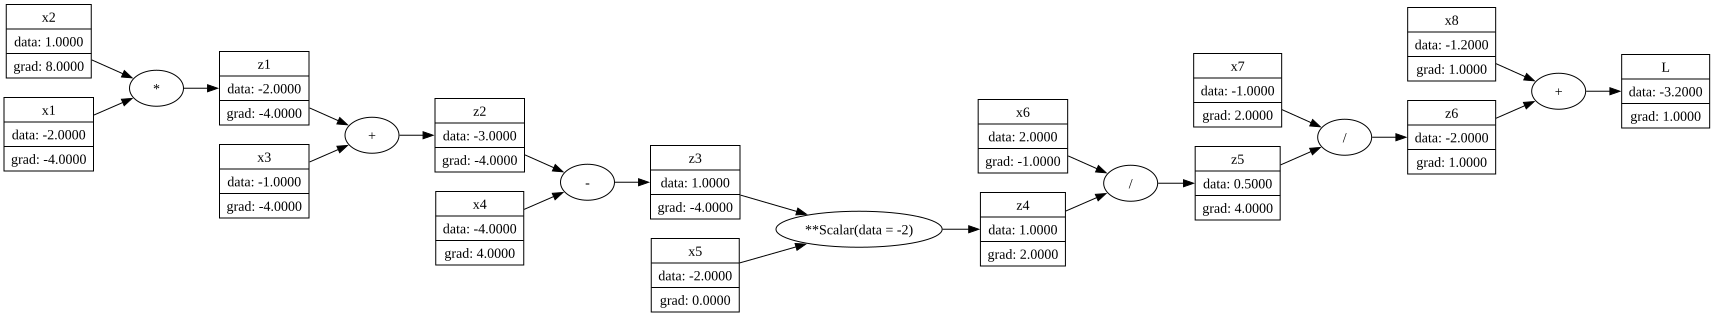

In [980]:
L_scalar.grad = dL_dL
x8, z6 = list(L_scalar._prev)[0], list(L_scalar._prev)[1]
z5, x7 = list(z6._prev)[0], list(z6._prev)[1]
x6, z4 = list(z5._prev)[0], list(z5._prev)[1]
x5, z3 = list(z4._prev)[0], list(z4._prev)[1]
x4, z2 = list(z3._prev)[0], list(z3._prev)[1]
x3, z1 = list(z2._prev)[0], list(z2._prev)[1]
x2, x1 = list(z1._prev)[0], list(z1._prev)[1]

# Manually fill the backward graph

# dL/dX
x1.grad = dL_dx1
x2.grad = dL_dx2
x3.grad = dL_dx3
x4.grad = dL_dx4
x5.grad = dL_dx5
x6.grad = dL_dx6
x7.grad = dL_dx7
x8.grad = dL_dx8
# dL/dZ
z1.grad = dL_dz1
z2.grad = dL_dz2
z3.grad = dL_dz3
z4.grad = dL_dz4
z5.grad = dL_dz5
z6.grad = dL_dz6
    
print("Computational Graph for forward and backward pass")
draw_dot(L_scalar)

## Optimizing L based on Gradients (Gradient Ascent)

In [981]:
dh = Scalar(dh, var_name="dh")

step_size = Scalar(0.03)
x1 += Scalar(dL_dx1) * step_size
x2 += Scalar(dL_dx2) * step_size
x3 += Scalar(dL_dx3) * step_size
x4 += Scalar(dL_dx4) * step_size
x5 += Scalar(dL_dx5) * step_size
x6 += Scalar(dL_dx6) * step_size
x7 += Scalar(dL_dx7) * step_size
x8 += Scalar(dL_dx8) * step_size
_, L_now, _ = h(x1 + dh, x2, x3, x4, x5, x6, x7, x8)
print(f"current L = {L_now.data:.3f} | Prev L = {L}")

current L = -1.202 | Prev L = -3.2


## Let's apply this for a simple Neural Network

------------------------------------------ Forward Pass ------------------------------------------
z1 = x1 * w1
z2 = x2 * w2
z3 = z1 + z2
z4 = z3 + b
y = tanh(z4)
------------------------------------------ Backward Pass ------------------------------------------
dy/dw1 = -1.5421
dy/dw2 = -0.2313
dy/dx1 = -0.2622
dy/dx2 = 0.5166
dy/db = 0.7711
dy/dz1 = 0.7711
dy/dz2 = 0.7711
dy/dz3 = 0.7711
dy/dz4 = 0.7711


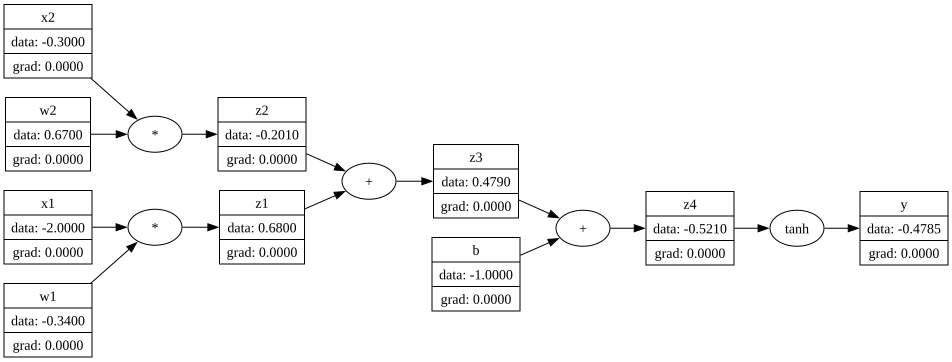

In [982]:
# Weights
w1 = Scalar(-0.34, var_name="w1")
w2 = Scalar(0.67, var_name="w2")

# bias
b = Scalar(-1, var_name="b")

# define input to the network
x1 = Scalar(-2, var_name="x1")
x2 = Scalar(-0.3, var_name="x2")

# Forward Pass
def forward(x1, x2, w1, w2, b):
    dh = Scalar(0.00000001)
    z1 = w1 * x1; z1.var_name = "z1"
    z2 = w2 * x2; z2.var_name = "z2"
    z3 = z1 + z2; z3.var_name = "z3"
    z4 = z3 + b; z4.var_name = "z4"
    y = z4.tanh(); y.var_name = "y"

    # Compute Local Gradients

    # dy/dz4
    z1 = w1 * x1; z1.var_name = "z1"
    z2 = w2 * x2; z2.var_name = "z2"
    z3 = z1 + z2; z3.var_name = "z3"
    z4 = z3 + b; z4.var_name = "z4"
    y_dz4 = (z4 + dh).tanh(); y.var_name = "y"
    dy_dz4 = (y_dz4 - y) / dh

    # dy/dz3
    z1 = w1 * x1; z1.var_name = "z1"
    z2 = w2 * x2; z2.var_name = "z2"
    z3 = z1 + z2; z3.var_name = "z3"
    z4_h = (z3 + dh) + b; z4.var_name = "z4"
    y_dz3 = z4_h.tanh(); y.var_name = "y"
    dy_dz3 = (y_dz3 - y) / dh

    # dy/dz2
    z1 = w1 * x1; z1.var_name = "z1"
    z2 = w2 * x2; z2.var_name = "z2"
    z3_h = z1 + (z2 + dh); z3.var_name = "z3"
    z4 = z3_h + b; z4.var_name = "z4"
    y_dz2 = z4.tanh(); y.var_name = "y"
    dy_dz2 = (y_dz2 - y) / dh

    # dy/dz1
    z1 = w1 * x1; z1.var_name = "z1"
    z2 = w2 * x2; z2.var_name = "z2"
    z3_h = (z1 + dh) + z2; z3.var_name = "z3"
    z4 = z3_h + b; z4.var_name = "z4"
    y_dz4 = z4.tanh(); y.var_name = "y"
    dy_dz1 = (y_dz4 - y) / dh

    return y, (dy_dz1.data, dy_dz2.data, dy_dz3.data, dy_dz4.data)

# Backward pass
def backward(x1, x2, w1, w2, b):
    dh = Scalar(0.00000001)
    y = forward(x1, x2, w1, w2, b)[0]
    dy_dx1 = (forward(x1 + dh, x2, w1, w2, b)[0] - y) / dh
    dy_dx2 = (forward(x1, x2 + dh, w1, w2, b)[0] - y) / dh
    dy_dw1 = (forward(x1, x2, w1 + dh, w2, b)[0] - y) / dh
    dy_dw2 = (forward(x1, x2, w1, w2 + dh, b)[0] - y) / dh
    dy_db = (forward(x1, x2, w1, w2, b + dh)[0] - y) / dh
    return dy_dx1.data, dy_dx2.data, dy_dw1.data, dy_dw2.data, dy_db.data

y, (dy_dz1, dy_dz2, dy_dz3, dy_dz4) = forward(x1, x2, w1, w2, b)
dy_dx1, dy_dx2, dy_dw1, dy_dw2, dy_db = backward(x1, x2, w1, w2, b)

print("------------------------------------------ Forward Pass ------------------------------------------")
print("z1 = x1 * w1")
print("z2 = x2 * w2")
print("z3 = z1 + z2")
print("z4 = z3 + b")
print("y = tanh(z4)")
print("------------------------------------------ Backward Pass ------------------------------------------")
print(f"dy/dw1 = {dy_dw1:.4f}")
print(f"dy/dw2 = {dy_dw2:.4f}")
print(f"dy/dx1 = {dy_dx1:.4f}")
print(f"dy/dx2 = {dy_dx2:.4f}")
print(f"dy/db = {dy_db:.4f}")
print(f"dy/dz1 = {dy_dz1:.4f}")
print(f"dy/dz2 = {dy_dz2:.4f}")
print(f"dy/dz3 = {dy_dz3:.4f}")
print(f"dy/dz4 = {dy_dz4:.4f}")
draw_dot(y)

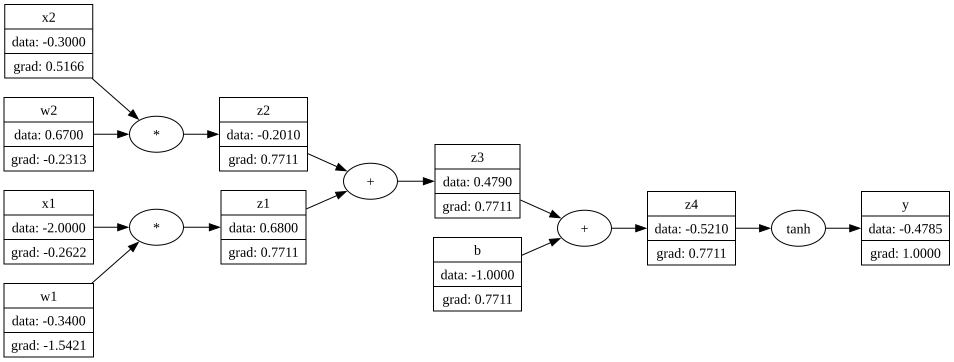

In [983]:
# Fill the Computational Graph Manually
y.grad = 1
z4 = y._prev[0]
z4.grad = dy_dz4
b, z3 = z4._prev
b.grad, z3.grad = dy_db, dy_dz3
z2, z1 = z3._prev
z2.grad, z1.grad = dy_dz2, dy_dz1
x1, w1 = z1._prev
x2, w2 = z2._prev
x1.grad, x2.grad, w1.grad, w2.grad = dy_dx1, dy_dx2, dy_dw1, dy_dw2
draw_dot(y)

In [984]:
a = Scalar(-3); a.var_name = "a"
b = Scalar(-7); b.var_name = "b"
c = a + b; c.var_name = "c"
print(f"result: {c.data}")
print(f"grad: {c.grad}")
print(f"prev: {c._prev}")
print(f"op: {c._op}")

result: -10
grad: 0
prev: (Scalar(data = -7), Scalar(data = -3))
op: +


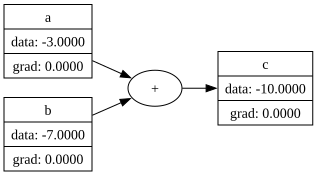

In [985]:
draw_dot(c)

## Let's do this using Local Gradients and Chain Rule

In [986]:
# for very simple expression: c = a + b; y = c * d
a = Scalar(-3); a.var_name = "a"
b = Scalar(-7); b.var_name = "b"
c = a + b; c.var_name = "c"
d = Scalar(2); d.var_name = "d"
y = d * c; y.var_name = "y"
print(y)

Scalar(data = -20)


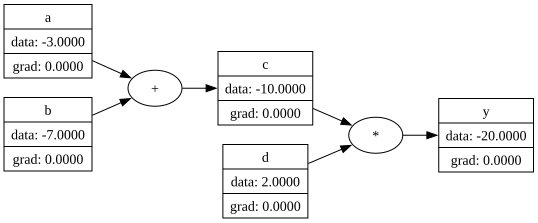

In [987]:
draw_dot(y)

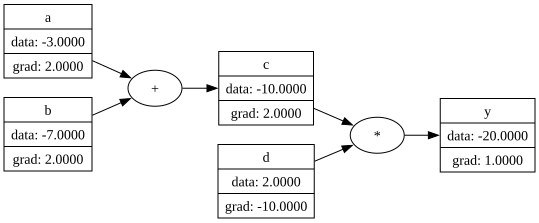

In [988]:
# Manually filling the Graidents
# dy/dy = 1, y = c * d => dy/dc = d; dy/dd = c; dy/da = dy/dc * dc/da = d * 1 = d; dy/da = c
y.grad = 1
d.grad = c.data
c.grad = d.data
a.grad, b.grad = c.grad * 1, c.grad * 1
draw_dot(y)

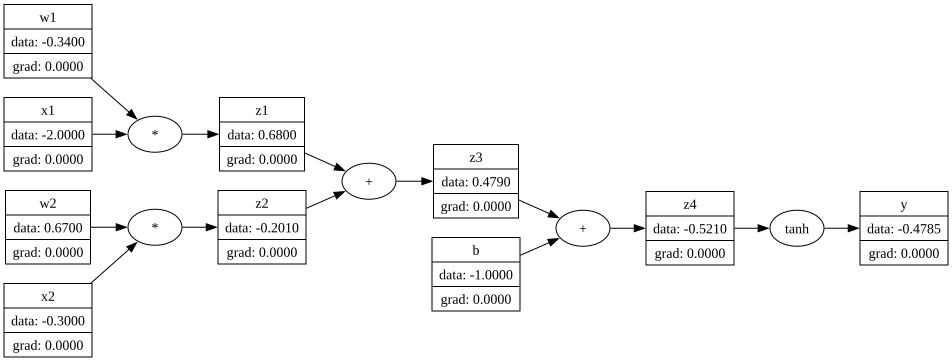

In [989]:
# Weights
w1 = Scalar(-0.34, var_name="w1")
w2 = Scalar(0.67, var_name="w2")

# bias
b = Scalar(-1, var_name="b")

# define input to the network
x1 = Scalar(-2, var_name="x1")
x2 = Scalar(-0.3, var_name="x2")

# Forward Pass
z1 = w1 * x1; z1.var_name = "z1"
z2 = w2 * x2; z2.var_name = "z2"
z3 = z1 + z2; z3.var_name = "z3"
z4 = z3 + b; z4.var_name = "z4"
y = z4.tanh(); y.var_name = "y"
draw_dot(y)

### Backpropagation through backward() 

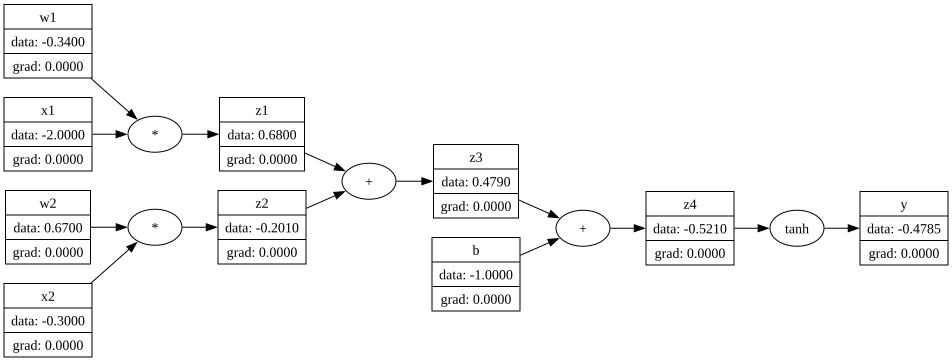

In [990]:
draw_dot(y)

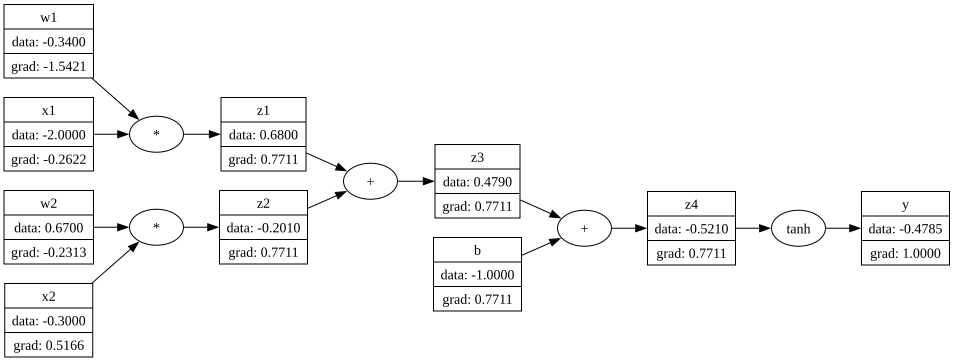

In [991]:
y.backward() # Calling backward on the final logit
draw_dot(y) # computational graph after backward pass

## Let's build a Neural Network

In [992]:
import random
class Neuron:
    def __init__(self, in_features: int):
        self.in_features = in_features
        self.weight = [Scalar(random.uniform(-1, 1)) for _ in range(in_features)]
        self.bias = Scalar(random.uniform(-1, 1))
    
    def __call__(self, x: Scalar):
        return self.forward(x)
    
    def forward(self, x: Scalar):
        y = []

        for xi, wi in zip(x, self.weight):
            y.append(xi * wi)

        act = sum(y, Scalar(0)) + self.bias

        tanh_act = act.tanh()
        return tanh_act
    
    def __repr__(self):
        return f"Neuron(in_features = {self.in_features})"
    
    def parameters(self):
        return self.weight + [self.bias]

class LinearLayer:
    def __init__(self, in_features: int, out_features: int):
        self.neurons = []
        self.in_features = in_features
        self.out_features = out_features
        for _ in range(out_features):
            self.neurons.append(Neuron(in_features))
    
    def forward(self, x: Scalar):
        layer_output = []
        for l in self.neurons: # [n1(10), n2(10)]
            ni = l(x)
            layer_output.append(ni)
        return layer_output if len(layer_output) > 1 else layer_output[0]
    
    def __call__(self, x: Scalar):
        return self.forward(x)
    
    def __repr__(self):
        return f"LinearLayer({self.in_features}, {self.out_features})"
    
    def parameters(self):
        self.param = []
        for n in self.neurons:
            self.param.extend(n.parameters())
        return self.param
    
class MLP:
    def __init__(self, in_features: int, hidden_dim: int, out_features: int, n_layers: int):
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.out_features = out_features
        self.n_layers = n_layers
        self.layers = []

        # Adding 1st layer
        self.layers.append(LinearLayer(in_features, hidden_dim))

        # Adding hidden dims
        for _ in range(n_layers - 2):
            self.layers.append(LinearLayer(hidden_dim, hidden_dim))
        
        # Adding Final Layer
        self.layers.append(LinearLayer(hidden_dim, out_features))
    
    def forward(self, x: Scalar):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def __call__(self, x: Scalar):
        return self.forward(x)
    
    def __repr__(self):
        return f"[LinearLayer({self.in_features}, {self.hidden_dim})] | [LinearLayer({self.hidden_dim}, {self.hidden_dim})] x {self.n_layers - 2} | [LinearLayer({self.hidden_dim}, {self.out_features})]"
    
    def parameters(self):
        self.mlp_params = []
        for layer in self.layers:
            self.mlp_params.extend(layer.parameters())
        return self.mlp_params

In [993]:
batch_size = 4
in_features = 3
hidden_dim = 5
n_layer = 10

xs = [
    [Scalar(random.uniform(-1, 1)) for _ in range(in_features)]
    for _ in range(batch_size)
]

mlp = MLP(
    in_features = in_features,
    hidden_dim = hidden_dim,
    out_features = 1,
    n_layers = n_layer
)

y_preds = [mlp(x) for x in xs]
y_true = [Scalar(-1.0), Scalar(1.0), Scalar(-1.0), Scalar(1.0)]

In [ ]:
# MSE Loss
loss = [(y - yp) ** 2 for y, yp in zip(y_true, y_preds)]
loss = sum(loss, Scalar(0.0)) / len(y_preds)
print(f"Loss = {loss.data:.4f}")

Loss = 1.2339


In [995]:
loss.backward()

In [996]:
draw_dot(loss)

In [997]:
len(mlp.parameters())

266

In [1016]:
lr = 0.01
for epoch in range(200):
    # forward pass
    y_preds = [mlp(x) for x in xs]
    loss = [(y - yp) ** 2 for y, yp in zip(y_true, y_preds)] # loss computation
    loss = sum(loss, Scalar(0.0)) / len(y_preds)
    
    # optimizer.zero_grad()
    for p in mlp.parameters():
        p.grad = 0 

    # loss.backward()
    loss.backward()

    # optimizer.step()
    for p in mlp.parameters():
        p.data -= p.grad * lr

    if epoch % 20 == 0:
        print(f"Loss = {loss.data:.4f}")

Loss = 0.0130
Loss = 0.0119
Loss = 0.0110
Loss = 0.0102
Loss = 0.0095
Loss = 0.0089
Loss = 0.0083
Loss = 0.0079
Loss = 0.0074
Loss = 0.0070


In [1017]:
y_preds, y_true

([Scalar(data = -0.9198512602134652),
  Scalar(data = 0.9252962514599199),
  Scalar(data = -0.920903654528316),
  Scalar(data = 0.9079386074856223)],
 [Scalar(data = -1.0),
  Scalar(data = 1.0),
  Scalar(data = -1.0),
  Scalar(data = 1.0)])